# **Predicting Vegetation Growth Risk for Tree Trimming Prioritization Using Machine Learning**

# Import Libraries

In [65]:
import pandas as pd
import numpy as np
import boto3
import s3fs
import matplotlib.pyplot as plt
import seaborn as sns
# Weather data library
from meteostat import Stations, Daily
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

# Connect SageMaker to S3

In [66]:
#Create S3 client using boto3
#This allows the notebook to communicate with S3
s3 = boto3.client('s3')

#Define your S3 bucket name where your datasets are stored
bucket = "vegetation-risk-ml"

#list files inside bucket
response = s3.list_objects_v2(Bucket=bucket)

#Print the names of the files in the bucket
for obj in response['Contents']:
    print(obj['Key'])

athena-results/
processed/
processed/forest/combined_forest_data.csv
raw/
raw/fire/
raw/fire/California_Historic_Fire_data.csv
raw/forest/
raw/forest/CA_PLOT.csv
raw/forest/CA_SUBPLOT.csv
raw/forest/CA_TREE.csv
raw/forest/CA_TREE_REGIONAL_BIOMASS.csv
raw/weather/
raw/weather/california_weather_data.csv


The datasets used in this project were originally downloaded from public government data sources- the U.S. Forest Service (FIA), CAL FIRE wildfire records and NOAA weather data accessed through the Meteostat library. After downloading, the files were manually uploaded to an Amazon S3 bucket. The datasets are accessed from Amazon S3 using SageMaker Studio notebooks for exploration and further processing.

# Load FIA(forest vegetation data) from S3

The FIA forest vegetation dataset consists of four tables: subplot information,plot information, tree characteristics, and biomass measurements. These files are stored in Amazon S3 and loaded into the SageMaker notebook for further analysis. 

In [67]:
#file path for FIA forest datasets inside S3 bucket
subplot_path = "s3://vegetation-risk-ml/raw/forest/CA_SUBPLOT.csv"
tree_path = "s3://vegetation-risk-ml/raw/forest/CA_TREE.csv"
biomass_path = "s3://vegetation-risk-ml/raw/forest/CA_TREE_REGIONAL_BIOMASS.csv"
plot_path = "s3://vegetation-risk-ml/raw/forest/CA_PLOT.csv"

In [68]:
# Load the CSV file from S3 into a pandas DataFrame
subplot = pd.read_csv(subplot_path, low_memory=False)
subplot.head(3)

,CN,PLT_CN,PREV_SBP_CN,INVYR,STATECD,UNITCD,COUNTYCD,PLOT,SUBP,SUBP_STATUS_CD,...,GROUND_TRAN_PTS_OTHER_RMRS,GROUND_TRAN_PTS_PEIS_RMRS,GROUND_TRAN_PTS_ROAD_RMRS,GROUND_TRAN_PTS_ROCK_RMRS,GROUND_TRAN_PTS_TRIS_RMRS,GROUND_TRAN_PTS_VEG_RMRS,GROUND_TRAN_PTS_WATER_RMRS,GROUND_TRAN_PTS_WOOD_RMRS,PREV_STATUSCD_RMRS,ROOTSEVCD_RMRS
0,59015,11839,NaN,1994,6,1,15,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,59042,11839,NaN,1994,6,1,15,1,2,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,59068,11839,NaN,1994,6,1,15,1,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
# Load the tree dataset from the specified file path into a pandas DataFrame.
trees = pd.read_csv(tree_path, low_memory=False)
trees.head(3)

,CN,PLT_CN,PREV_TRE_CN,INVYR,STATECD,UNITCD,COUNTYCD,PLOT,SUBP,TREE,...,DRYBIO_STUMP_BARK,DRYBIO_BOLE_BARK,DRYBIO_BRANCH,DRYBIO_FOLIAGE,DRYBIO_SAWLOG_BARK,PREV_ACTUALHT_FLD,PREV_HT_FLD,UTILCLCD,SPCD_ID_CD,ABNORMAL_TERMINATION
0,675267,11839,NaN,1994,6,1,15,1,1,675267,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,675268,11839,NaN,1994,6,1,15,1,1,675268,...,17.718832,469.383932,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,675269,11839,NaN,1994,6,1,15,1,1,675269,...,10.354492,143.559569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [70]:
# Load the biomass dataset from the specified file path into a pandas DataFrame
biomass = pd.read_csv(biomass_path, low_memory=False)
biomass.head(3)

,TRE_CN,STATECD,REGIONAL_DRYBIOT,REGIONAL_DRYBIOM,CREATED_BY,CREATED_DATE,CREATED_IN_INSTANCE,MODIFIED_BY,MODIFIED_DATE,MODIFIED_IN_INSTANCE,REGIONAL_DRYBIOSL
0,44784050020004,6,181.351518,94.186487,RWANEK,2012-07-26 14:10:00,20004,FSJASONBROWN,2020-07-11 23:46:37,290487,NaN
1,44784051020004,6,244.463259,167.318417,RWANEK,2012-07-26 14:10:00,20004,FSJASONBROWN,2020-07-11 23:46:37,290487,152.313767
2,44784052020004,6,356.127994,204.940133,RWANEK,2012-07-26 14:10:00,20004,FSJASONBROWN,2020-07-11 23:46:37,290487,187.352578


In [71]:
##load plot dataset from S3 into pandas DataFrame
plot = pd.read_csv(plot_path, low_memory=False)
plot.head(3)

,CN,SRV_CN,CTY_CN,PREV_PLT_CN,INVYR,STATECD,UNITCD,COUNTYCD,PLOT,PLOT_STATUS_CD,...,MANUAL_RMRS,PAC_ISLAND_PNWRS,PLOT_SEASON_NERS,PREV_MICROPLOT_LOC_RMRS,PREV_PLOT_STATUS_CD_RMRS,REUSECD1,REUSECD2,REUSECD3,GRND_LYR_SAMPLING_STATUS_CD,GRND_LYR_SAMPLING_METHOD_CD
0,11839,153648000020004,9010497,NaN,1994,6,1,15,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11840,153648000020004,9010497,NaN,1994,6,1,15,2,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11841,153648000020004,9010497,NaN,1994,6,1,15,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [72]:
#check data structure of subplot dataset
subplot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178917 entries, 0 to 178916
Data columns (total 48 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   CN                             178917 non-null  int64  
 1   PLT_CN                         178917 non-null  int64  
 2   PREV_SBP_CN                    3384 non-null    float64
 3   INVYR                          178917 non-null  int64  
 4   STATECD                        178917 non-null  int64  
 5   UNITCD                         178917 non-null  int64  
 6   COUNTYCD                       178917 non-null  int64  
 7   PLOT                           178917 non-null  int64  
 8   SUBP                           178917 non-null  int64  
 9   SUBP_STATUS_CD                 178917 non-null  int64  
 10  POINT_NONSAMPLE_REASN_CD       9005 non-null    float64
 11  MICRCOND                       155600 non-null  float64
 12  SUBPCOND                      

In [73]:
#check data structure of plot dataset
plot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43814 entries, 0 to 43813
Data columns (total 63 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   CN                              43814 non-null  int64  
 1   SRV_CN                          43814 non-null  int64  
 2   CTY_CN                          43814 non-null  int64  
 3   PREV_PLT_CN                     22257 non-null  float64
 4   INVYR                           43814 non-null  int64  
 5   STATECD                         43814 non-null  int64  
 6   UNITCD                          43814 non-null  int64  
 7   COUNTYCD                        43814 non-null  int64  
 8   PLOT                            43814 non-null  int64  
 9   PLOT_STATUS_CD                  43814 non-null  int64  
 10  PLOT_NONSAMPLE_REASN_CD         2051 non-null   float64
 11  MEASYEAR                        43814 non-null  int64  
 12  MEASMON                         

In [74]:
#check data structure of tree dataset
trees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 446320 entries, 0 to 446319
Columns: 198 entries, CN to ABNORMAL_TERMINATION
dtypes: float64(181), int64(13), object(4)
memory usage: 674.2+ MB


In [75]:
#check data structure of biomass dataset
biomass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390955 entries, 0 to 390954
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   TRE_CN                390955 non-null  int64  
 1   STATECD               390955 non-null  int64  
 2   REGIONAL_DRYBIOT      316455 non-null  float64
 3   REGIONAL_DRYBIOM      329615 non-null  float64
 4   CREATED_BY            390955 non-null  object 
 5   CREATED_DATE          390955 non-null  object 
 6   CREATED_IN_INSTANCE   390955 non-null  int64  
 7   MODIFIED_BY           390955 non-null  object 
 8   MODIFIED_DATE         390955 non-null  object 
 9   MODIFIED_IN_INSTANCE  390955 non-null  int64  
 10  REGIONAL_DRYBIOSL     137020 non-null  float64
dtypes: float64(3), int64(4), object(4)
memory usage: 32.8+ MB


#### Merge tree,plot,biomass and subplot dataset

The four FIA datasets are merged to create a unified forest vegetation dataset. The merge connects tree measurements with subplot environmental characteristics and biomass estimates.

In [76]:
#Merge trees and subplot.To save memory, we will choose needed columns only
combined_forest = trees[["CN", "PLT_CN", "DIA", "HT", "SPCD", "STATUSCD"]].merge(subplot[["PLT_CN", "SLOPE", "ASPECT"]],on="PLT_CN",how="left")

#Merge the resulting dataframe with biomass dataframe on tree identifier.Again, select needed columns to save memory
combined_forest = combined_forest.merge(biomass[["TRE_CN", "REGIONAL_DRYBIOT", "REGIONAL_DRYBIOM"]],left_on="CN",right_on="TRE_CN",how="left")

plot_clean = plot[["CN", "LAT", "LON", "COUNTYCD"]].rename(columns={"CN": "PLT_CN"})

# Merge plot 
combined_forest = combined_forest.merge(plot_clean, on="PLT_CN", how="left")
# Remove duplicates
combined_forest = combined_forest.drop_duplicates()

#Check the resulting dataframe
print("Merged forest dataset shape:", combined_forest.shape)
combined_forest.head()

Merged forest dataset shape: (1687167, 14)


,CN,PLT_CN,DIA,HT,SPCD,STATUSCD,SLOPE,ASPECT,TRE_CN,REGIONAL_DRYBIOT,REGIONAL_DRYBIOM,LAT,LON,COUNTYCD
0,675267,11839,3.9,43.0,631.0,1,50.0,225.0,675267.0,NaN,0.000000,41.478172,-123.946777,15
2,675267,11839,3.9,43.0,631.0,1,60.0,225.0,675267.0,NaN,0.000000,41.478172,-123.946777,15
4,675267,11839,3.9,43.0,631.0,1,40.0,180.0,675267.0,NaN,0.000000,41.478172,-123.946777,15
5,675268,11839,24.1,95.0,202.0,1,50.0,225.0,675268.0,NaN,2835.999965,41.478172,-123.946777,15
7,675268,11839,24.1,95.0,202.0,1,60.0,225.0,675268.0,NaN,2835.999965,41.478172,-123.946777,15


In [77]:
#Missing values
(combined_forest.isnull().mean() * 100).round(2)

CN                   0.00
PLT_CN               0.00
DIA                  7.44
HT                   7.44
SPCD                 0.00
STATUSCD             0.00
SLOPE                2.49
ASPECT               2.49
TRE_CN              12.95
REGIONAL_DRYBIOT    27.90
REGIONAL_DRYBIOM    24.81
LAT                  0.00
LON                  0.00
COUNTYCD             0.00
dtype: float64

In [78]:
combined_forest[['DIA','HT','SLOPE','REGIONAL_DRYBIOT','REGIONAL_DRYBIOM']].describe().round(2)

,DIA,HT,SLOPE,REGIONAL_DRYBIOT,REGIONAL_DRYBIOM
count,1561713.00,1561714.00,1645204.00,1216483.00,1268576.00
mean,14.70,57.82,37.88,2518.91,1773.81
std,11.92,39.81,22.90,6170.25,4012.51
min,1.00,1.00,0.00,0.42,0.00
25%,6.30,28.00,20.00,133.06,88.50
50%,10.00,46.00,35.00,394.91,312.13
75%,22.30,80.00,55.00,2485.09,1970.00
max,212.10,325.00,155.00,582558.91,347081.59


In [79]:
#Save this merged dataframe to S3 for future use
combined_forest.to_csv("s3://vegetation-risk-ml/processed/forest/combined_forest_data.csv", index=False)

# Load CALFIRE dataset from S3

The CAL FIRE dataset contains wildfire perimeter records for California, originaly downloaded from public website and uploaded manully into S3 in raw/fire folder.This dataset provides information on fire location, cause, start date, and burned area.

In [80]:
# Path to wildfire dataset stored in S3
fire_path = "s3://vegetation-risk-ml/raw/fire/California_Historic_Fire_data.csv"

# Load wildfire dataset
fire = pd.read_csv(fire_path)

# Display dataset shape and rows
print("Fire dataset shape:", fire.shape)
fire.head(3)

Fire dataset shape: (3372, 23)


,incident_name,incident_is_final,incident_date_last_update,incident_date_created,incident_administrative_unit,incident_administrative_unit_url,incident_county,incident_location,incident_acres_burned,incident_containment,...,incident_latitude,incident_type,incident_id,incident_url,incident_date_extinguished,incident_dateonly_extinguished,incident_dateonly_created,is_active,calfire_incident,notification_desired
0,Bridge Fire,Y,2018-01-09T13:46:00Z,2017-10-31T11:22:00Z,Shasta-Trinity National Forest,NaN,Shasta,"I-5 and Turntable Bay, 7 miles NE of Shasta Lake",37.0,100.0,...,40.774000,NaN,2ca11d45-8139-4c16-8af0-880d99b21e82,https://www.fire.ca.gov/incidents/2017/10/31/b...,2018-01-09T13:46:00Z,2018-01-09,2017-10-31,N,False,False
1,Pala Fire,Y,2020-09-16T14:07:35Z,2009-05-24T14:56:00Z,CAL FIRE San Diego Unit,NaN,San Diego,"Hwy 76 and Pala Temecula, northwest of Pala",122.0,100.0,...,1.000000,Wildfire,8f61f461-552d-4538-b186-35ab030da416,https://www.fire.ca.gov/incidents/2009/5/24/pa...,2009-05-25T00:00:00Z,2009-05-25,2009-05-24,N,True,False
2,River Fire,Y,2022-10-24T11:39:23Z,2013-02-24T08:16:00Z,CAL FIRE San Bernardino Unit,NaN,Inyo,"south of Narrow Gauge Rd & north of Hwy 136, e...",407.0,100.0,...,36.602575,NaN,094719ba-a47b-4abb-9ec5-a506b2b9fd23,https://www.fire.ca.gov/incidents/2013/2/24/ri...,2013-02-28T20:00:00Z,2013-02-28,2013-02-24,N,True,False


In [81]:
#Basic structure of fire dataset
print(fire.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3372 entries, 0 to 3371
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   incident_name                     3372 non-null   object 
 1   incident_is_final                 3372 non-null   object 
 2   incident_date_last_update         3372 non-null   object 
 3   incident_date_created             3372 non-null   object 
 4   incident_administrative_unit      3307 non-null   object 
 5   incident_administrative_unit_url  0 non-null      float64
 6   incident_county                   3362 non-null   object 
 7   incident_location                 3372 non-null   object 
 8   incident_acres_burned             3319 non-null   float64
 9   incident_containment              3320 non-null   float64
 10  incident_control                  119 non-null    object 
 11  incident_cooperating_agencies     1691 non-null   object 
 12  incide

In [82]:
#missing values in fire dataset
print(fire.isnull().sum())

incident_name                          0
incident_is_final                      0
incident_date_last_update              0
incident_date_created                  0
incident_administrative_unit          65
incident_administrative_unit_url    3372
incident_county                       10
incident_location                      0
incident_acres_burned                 53
incident_containment                  52
incident_control                    3253
incident_cooperating_agencies       1681
incident_longitude                     0
incident_latitude                      0
incident_type                       1234
incident_id                            0
incident_url                           0
incident_date_extinguished           741
incident_dateonly_extinguished       741
incident_dateonly_created              0
is_active                              0
calfire_incident                       0
notification_desired                   0
dtype: int64


In [83]:
#duplicated values in fire dataset
print(fire.duplicated().sum())

0


# Load Weather Data Using Meteostat

Weather stations across California are retrieved using the Meteostat API. These stations provide historical weather measurements such as temperature and precipitation.

In [84]:

# get stations
stations = Stations().region('US', 'CA').fetch(200).reset_index()
stations = stations[['id', 'latitude', 'longitude']]
stations.columns = ['station', 'lat', 'lon']

# Weather download
start, end = datetime(2015,1,1), datetime(2026,1,1)

weather_data = []
for s in stations['station'][:100]:
    try:
        data = Daily(s, start, end).fetch()
        if not data.empty:
            data = data.reset_index()
            data['station'] = s
            weather_data.append(data)
    except Exception as e:
        print(f"Error for station {s}: {e}")


weather = pd.concat(weather_data, ignore_index=True)

#Merge weather data with station info. 
weather = weather.merge(stations, on='station', how='left')
#Select relevant columns to save memory
weather = weather[['time','tavg', 'prcp', 'wspd', 'station', 'lat', 'lon','pres','tmin','tmax']]
weather["time"] = pd.to_datetime(weather["time"]).dt.date
#drop missing values
weather = weather.dropna(subset= ["lat", "lon"])

print(f"Total: {len(weather)} records from {weather['station'].nunique()} stations")
print(weather.head())

Total: 309116 records from 91 stations
         time  tavg  prcp  wspd station      lat       lon  pres  tmin  tmax
0  2020-11-05  13.5   NaN   NaN   69007  36.6815 -121.7617   NaN   8.0  27.0
1  2020-11-06  12.1   NaN   NaN   69007  36.6815 -121.7617   NaN   8.0  15.0
2  2020-11-07   9.9   NaN   NaN   69007  36.6815 -121.7617   NaN   6.0  13.0
3  2020-11-08   9.1   NaN   NaN   69007  36.6815 -121.7617   NaN   2.0  12.0
4  2020-11-09   5.5   NaN   NaN   69007  36.6815 -121.7617   NaN  -1.0  13.0


In [85]:
#Summary statistics of weather data
weather[["tavg","prcp","wspd","pres"]].describe().round(2)

,tavg,prcp,wspd,pres
count,301803.00,259384.00,297457.00,263940.00
mean,16.65,1.13,10.89,1015.32
std,7.21,6.23,6.21,4.98
min,-28.70,0.00,0.00,977.90
25%,11.70,0.00,6.80,1012.00
50%,15.80,0.00,9.40,1014.90
75%,21.10,0.00,13.30,1018.50
max,43.70,1265.30,125.60,1045.90


The average temperature across weather stations is 16 degC, with values ranging from −28 degC to 43 degC.Precipitation has a mean of 1.13 mm and a median of 0 mm, indicating that most observations experience little or no rainfall. Wind speeds average is 10.65 km/h with a maximum of 156 km/h, and atmospheric pressure shows a mean of 1015 hPa.

In [86]:
#missing values
print(weather.isnull().sum())

time           0
tavg        7313
prcp       49732
wspd       11659
station        0
lat            0
lon            0
pres       45176
tmin         624
tmax         624
dtype: int64


In [87]:
# save the weather data to S3 for future use
weather.to_csv("s3://vegetation-risk-ml/raw/weather/california_weather_data.csv", index=False)

# INITIAL DATA EXPLORATION

### What are the distributions and relationships among key weather variables (temperature, precipitation,atmospheric pressure and wind speed) across California weather stations?
    

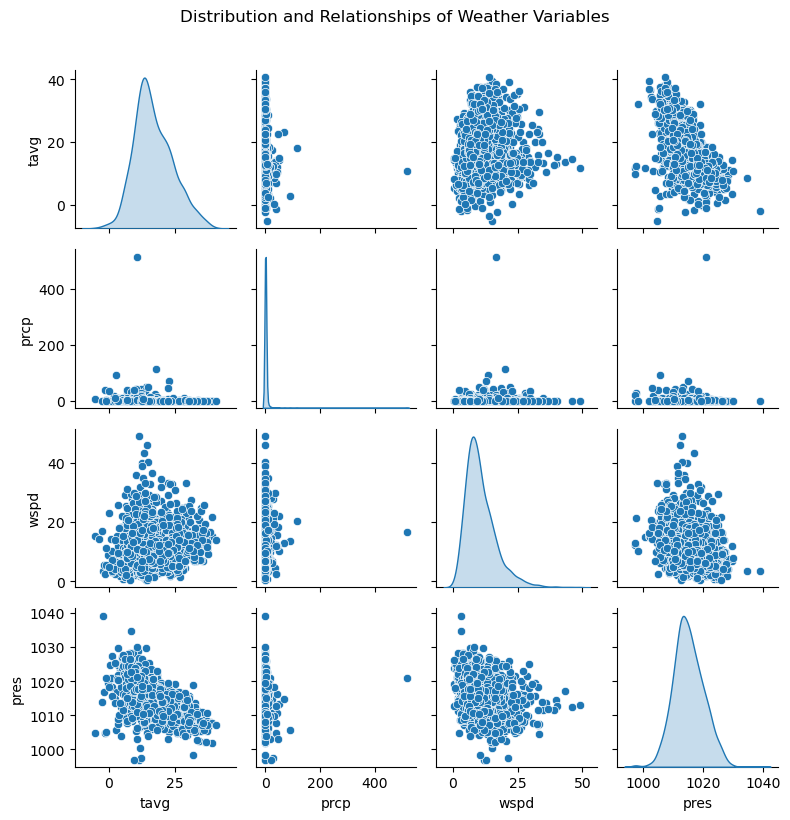

In [88]:
#select key weather variables for analysis
weather_subset = weather[["tavg","prcp","wspd","pres"]]
#plot pairwise relationships and distributions of weather variables using seaborn
sns.pairplot(weather_subset.sample(2000),diag_kind="kde", height=2)

plt.suptitle("Distribution and Relationships of Weather Variables", y=1.02)
plt.tight_layout()
plt.show()

The pairplot shows the distribution and relationships between temperature, precipitation,presssure and wind speed across California weather stations. The temperature variable show positive correlation. Temperature and pressure appears normally distributed, precipitation shows right-skewed, indicating that most days have little or no rainfall which can be a risk factor for dry vegetation. Wind speed shows right skewed with very few high speed winds. The scatter relationships suggest weak correlations between these variables, indicating that temperature, precipitation, pressure and wind speed vary relatively independently across the dataset.

### Which forest and terrain variables(slope and Aspect) are most strongly associated with vegetation biomass?

Identifying which forest(diameter and height) and terrain(slope and aspect) variables are most strongly related with vegetation biomass is important because these factors influence sunlight exposure, moisture availability, and soil conditions, which ultimately affect vegetation growth.Forests with larger trees and higher biomass provide more fuel, while terrain influence how quickly fires spread and how dry the vegetation becomes.

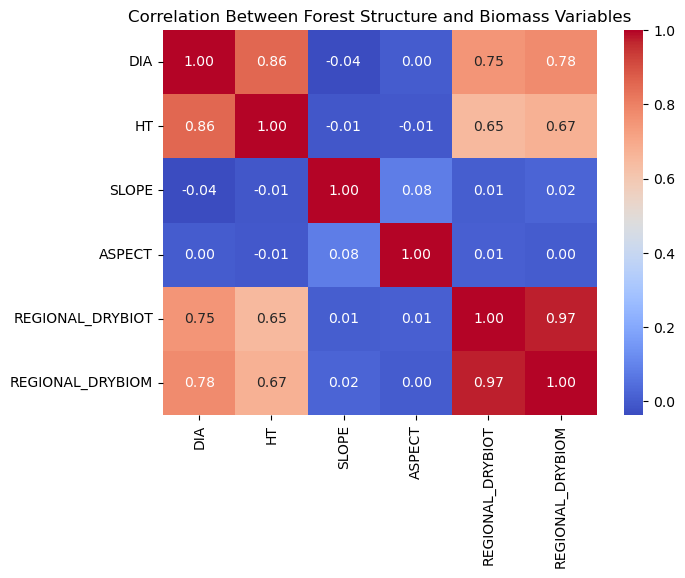

In [89]:
plt.figure(figsize=(7,5))
#select key forest structure and biomass variables for correlation analysis
corr_features = combined_forest[['DIA','HT','SLOPE','ASPECT','REGIONAL_DRYBIOT','REGIONAL_DRYBIOM']]
#plot heatmap of correlations between selected forest structure and biomass variables
sns.heatmap(corr_features.corr(),annot=True,cmap="coolwarm",fmt=".2f")

plt.title("Correlation Between Forest Structure and Biomass Variables")
plt.show()

The correlation heatmap shows the relationships between tree characteristics(tee diameter,tree height), terrain variables, and vegetation biomass. 

Tree diameter and height show positive correlations with biomass variables, suggesting that larger trees contribute to higher vegetation fuel loads.So areas with many large trees may require more vegetation management to reduce wildfire fuel accumulation.

REGIONAL_DRYBIOT and REGIONAL_DRYBIOM shows strongly correlated(multicollinearity).Because these variables represent similar measurements of dry biomass, one of them may be sufficient for modeling purposes.

Steeper slopes combined with high biomass could increase wildfire spread risk.These areas require targeted vegetation trimming to reduce potential fire hazards.

### Is wildfire size distribution skewed toward extreme events?

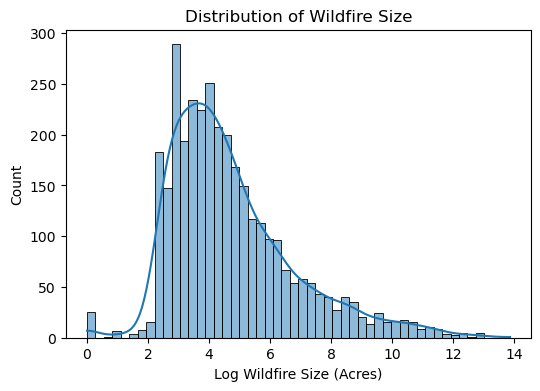

In [90]:

plt.figure(figsize=(6,4))
#plot histogram of wildfire size distribution using log scale to handle skewness
sns.histplot(np.log1p(fire["incident_acres_burned"]),kde=True, bins=50)

plt.xlabel("Log Wildfire Size (Acres)")
plt.title("Distribution of Wildfire Size")
plt.show()

Plot shows Wildfire data is right-skewed.Most fires burn small areas, while a small number of large fires account for a significant portion of total burned land. This pattern is common in wildfire datasets and highlights the importance of identifying conditions that lead to extreme fire events.

### What is the distribution of vegetation biomass across forest plots?

This directly uses your forest dataset and helps understand fuel load, which is important for wildfire risk.

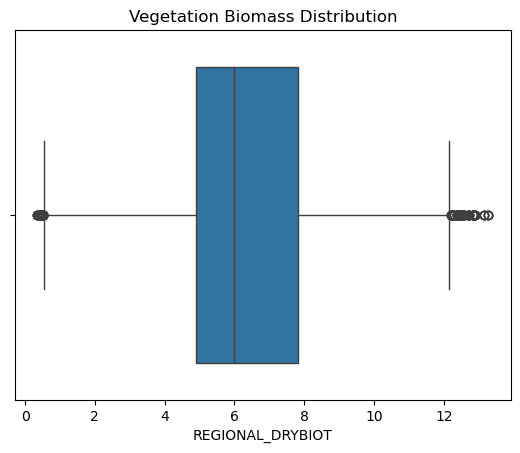

In [91]:
#plot boxplot of regional dry biomass distribution
sns.boxplot(x=np.log1p(combined_forest["REGIONAL_DRYBIOT"].dropna()))

plt.title("Vegetation Biomass Distribution")
plt.show()

The boxplot shows the distribution of vegetation biomass (REGIONAL_DRYBIOT). The median value is around 6, while the interquartile range lies between 5 and 8. The whiskers extend from about 0.5 to around 12,showing the spread of the data. A few outliers above 12 suggest that some regions have unusually high vegetation biomass compared to the majority of the dataset.These high-biomass areas may represent dense vegetation and which can act as larger fuel sources and can increase wildfire intensity if ignition occurs.

### Where are wildfire incidents geographically concentrated across California?

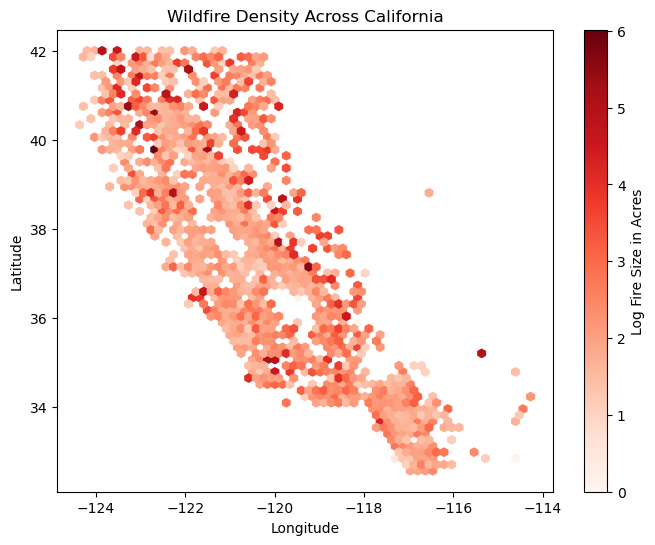

In [92]:
plt.figure(figsize=(8,6))
#remove invalid coordinates
fire_plt = fire[(fire["incident_longitude"].between(-125,-114)) & (fire["incident_latitude"].between(32,42))]
#plot the hexbin
scatter = plt.hexbin(x=fire_plt["incident_longitude"],y=fire_plt["incident_latitude"],C=np.log10(fire_plt["incident_acres_burned"] + 1),gridsize=60,cmap="Reds",mincnt=1)
bar = plt.colorbar(scatter)
bar.set_label("Log Fire Size in Acres")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Wildfire Density Across California")
plt.show()

The hexbin plot shows the spatial distribution of wildfire incidents across California using geographic coordinates. The color gradient indicates the logarithm of fire size in acres, with darker hexagons indicating locations where larger fires occurred. Larger fires appear in several parts of Northern California and some areas of Southern California, while the Central Valley shows fewer wildfire incidents.These spatial patterns can help identify regions where vegetation management and tree trimming should be prioritized to reduce wildfire risk.

### How does the number of wildfire incidents vary across different months of the year in California?

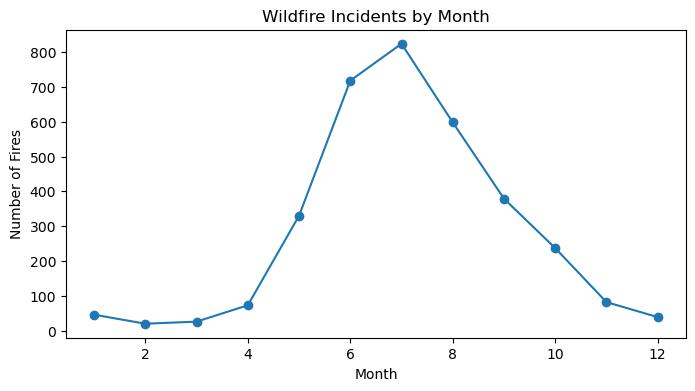

In [93]:

# Convert to datetime
fire["incident_date_created"] = pd.to_datetime(fire["incident_date_created"])

# Extract month
fire["month"] = fire["incident_date_created"].dt.month

# Count fires per month
fires_per_month = fire.groupby("month").size()

# Plot
plt.figure(figsize=(8,4))
fires_per_month.plot(kind="line", marker="o")

plt.xlabel("Month")
plt.ylabel("Number of Fires")
plt.title("Wildfire Incidents by Month")
plt.show()

The number of fires peaks during the summer months, particularly in July and August, before gradually declining in the fall. This pattern suggests that warmer temperatures and drier vegetation conditions during summer months contribute to higher wildfire activity in California.